# Phase 9 — Final Evaluation

Assembles all results into publication-ready tables and figures.

Contents:
1. Load all model predictions
2. Bootstrap 95% confidence intervals
3. Statistical significance (DeLong + McNemar)
4. Cross-dataset performance breakdown
5. Segmentation summary
6. Complete paper results table
7. Final ROC figure (300 DPI)
8. Error analysis — FN breakdown
9. Full output summary


In [1]:
import sys
from pathlib import Path

def _find_project_root(start, marker='config.py'):
    for parent in [start, *start.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Cannot find project root from {start}')

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Project root: D:\Machine Learning\glaucoma detection project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import roc_auc_score

from config import RESULTS_DIR, FIGURES_DIR, SEED
from data.dataset_loader import load_all_datasets
from models.classical_ml import load_trained_models, compute_metrics
from evaluation.final_eval import (
    bootstrap_metrics, delong_auc_test, mcnemar_test,
    cross_dataset_metrics, make_results_table,
)

plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 9.1 Load all predictions

In [3]:
df_all  = load_all_datasets(include=['ACRIMA','RIMONE','AIROGS'], airogs_max_samples=2000)
test_df = df_all[df_all['split']=='test'].reset_index(drop=True)

cache    = joblib.load(RESULTS_DIR / 'features_cache.pkl')
X        = cache['X']
y        = cache['y']
valid_df = cache['valid_df']
test_mask = valid_df['split'] == 'test'
X_test    = X[test_mask]
y_test    = y[test_mask]
test_meta = valid_df[test_mask].reset_index(drop=True)

cnn_results = joblib.load(RESULTS_DIR / 'cnn_test_results.pkl')
y_prob_cnn  = np.array(cnn_results['y_prob'])
y_pred_cnn  = np.array(cnn_results['y_pred'])
y_true_cnn  = np.array(cnn_results['y_true'])

trained_models = load_trained_models()
ml_probs = {n: m.predict_proba(X_test)[:,1] for n, m in trained_models.items()}
ml_preds = {n: m.predict(X_test)            for n, m in trained_models.items()}

print(f'Test samples : {len(y_test)}  (Classical ML)')
print(f'Test samples : {len(y_true_cnn)}  (CNN)')
print(f'Glaucoma     : {int(y_true_cnn.sum())}   Normal: {int((y_true_cnn==0).sum())}')

[ACRIMA]  Total:   705  |  Glaucoma:  396  |  Normal:  309
[RIMONE]  Total:   485  |  Glaucoma:  172  |  Normal:  313
[AIROGS]  Total:  3540  |  Glaucoma: 1770  |  Normal: 1770

────────────────────────────────────────────────────
  COMBINED  Total   : 4730
            Glaucoma: 2338
            Normal  : 2392
────────────────────────────────────────────────────
Loaded: LogisticRegression ← D:\Machine Learning\glaucoma detection project\outputs\models\LogisticRegression_best.pkl
Loaded: SVM_RBF ← D:\Machine Learning\glaucoma detection project\outputs\models\SVM_RBF_best.pkl
Loaded: RandomForest ← D:\Machine Learning\glaucoma detection project\outputs\models\RandomForest_best.pkl
Test samples : 1050  (Classical ML)
Test samples : 1050  (CNN)
Glaucoma     : 500   Normal: 550


## 9.2 Bootstrap 95% CI (2000 resamples)

In [4]:
ci_results = {}
for name in trained_models:
    print(f'  Bootstrapping {name}...')
    ci_results[name] = bootstrap_metrics(y_test, ml_probs[name])

print('  Bootstrapping CNN (ResNet18)...')
ci_results['CNN (ResNet18)'] = bootstrap_metrics(y_true_cnn, y_prob_cnn)

print(f'\n{"Model":<22} {"AUC":>8}  {"95% CI"}')
print('─' * 52)
for name, ci in ci_results.items():
    a = ci['auc']
    print(f'{name:<22} {a["mean"]:>8.4f}  [{a["lower"]:.4f} – {a["upper"]:.4f}]')

  Bootstrapping LogisticRegression...
  Bootstrapping SVM_RBF...
  Bootstrapping RandomForest...
  Bootstrapping CNN (ResNet18)...

Model                       AUC  95% CI
────────────────────────────────────────────────────
LogisticRegression       0.7126  [0.6808 – 0.7434]
SVM_RBF                  0.7888  [0.7597 – 0.8155]
RandomForest             0.7674  [0.7399 – 0.7940]
CNN (ResNet18)           0.9445  [0.9305 – 0.9574]


## 9.3 Statistical significance — DeLong + McNemar

In [5]:
n = min(len(y_true_cnn), len(y_test))

print('DeLong AUC test: CNN vs classical ML')
print(f'{"Comparison":<38} {"Z":>7} {"p-value":>10}  Sig')
print('─' * 62)
for name in trained_models:
    z, p = delong_auc_test(y_true_cnn[:n], y_prob_cnn[:n], ml_probs[name][:n])
    sig  = ('***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns')
    print(f'{f"CNN vs {name}":<38} {z:>7.3f} {p:>10.4f}  {sig}')

print(f'\nMcNemar test: CNN vs SVM_RBF (best classical model)')
chi2, p = mcnemar_test(y_true_cnn[:n], y_pred_cnn[:n], ml_preds['SVM_RBF'][:n])
sig = ('***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns')
print(f'  chi2 = {chi2:.3f}   p = {p:.4f}   {sig}')

DeLong AUC test: CNN vs classical ML
Comparison                                   Z    p-value  Sig
──────────────────────────────────────────────────────────────
CNN vs LogisticRegression               13.488     0.0000  ***
CNN vs SVM_RBF                          10.112     0.0000  ***
CNN vs RandomForest                     11.072     0.0000  ***

McNemar test: CNN vs SVM_RBF (best classical model)
  chi2 = 98.935   p = 0.0000   ***


## 9.4 Cross-dataset breakdown — CNN

In [6]:
cnn_test_df = test_df.copy()
n = min(len(cnn_test_df), len(y_true_cnn))
cnn_test_df = cnn_test_df.iloc[:n].copy()
cnn_test_df['y_pred'] = y_pred_cnn[:n]
cnn_test_df['y_prob'] = y_prob_cnn[:n]

cross_df = cross_dataset_metrics(cnn_test_df)
cross_df.to_csv(RESULTS_DIR / 'cross_dataset_cnn.csv', index=False)
print('CNN — Cross-Dataset Performance')
display(cross_df.set_index('Dataset'))

CNN — Cross-Dataset Performance


,N,Glaucoma,Normal,AUC,Sensitivity,Specificity,F1,Accuracy
Dataset,,,,,,,,
ACRIMA,106,59,47,1.0000,0.9322,1.0000,0.9649,0.9623
AIROGS,770,385,385,0.9601,0.9377,0.8857,0.9139,0.9117
RIMONE,174,56,118,0.8295,0.8929,0.5169,0.6135,0.6379
Overall,1050,500,550,0.9445,0.9320,0.8164,0.8735,0.8714


## 9.5 Cross-dataset bar chart

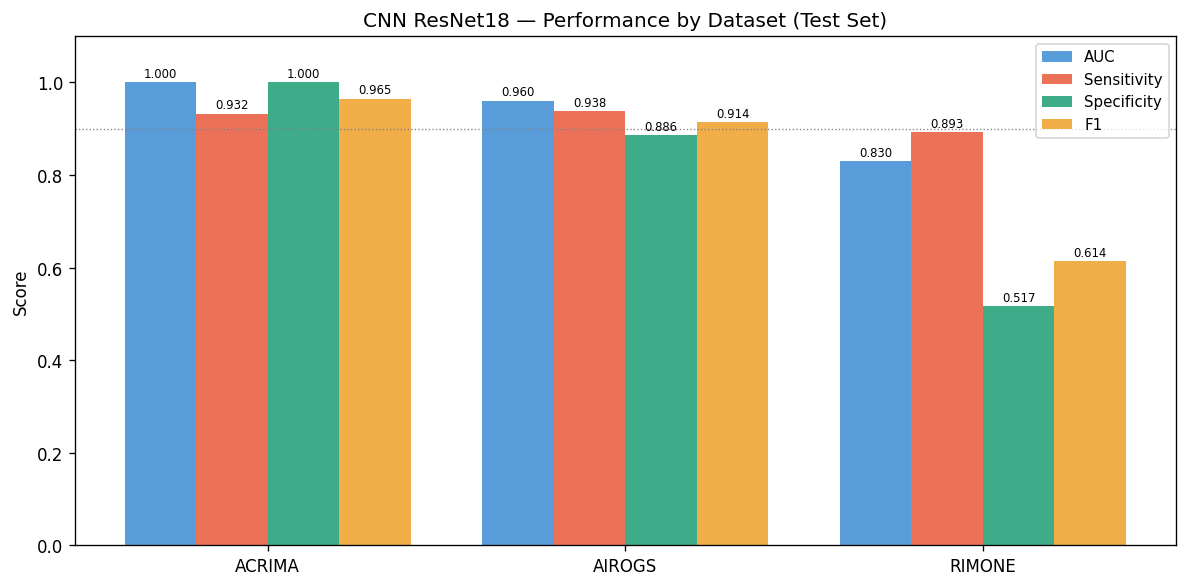

In [7]:
metrics_plot = ['AUC', 'Sensitivity', 'Specificity', 'F1']
plot_df  = cross_df[cross_df['Dataset'] != 'Overall']
x, w     = np.arange(len(plot_df)), 0.2
colours  = ['#3B8BD4', '#E8593C', '#1D9E75', '#EF9F27']

fig, ax = plt.subplots(figsize=(10, 5))
for i, (met, col) in enumerate(zip(metrics_plot, colours)):
    bars = ax.bar(x + i*w, plot_df[met].values, w, label=met, color=col, alpha=0.85)
    for bar, val in zip(bars, plot_df[met].values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + w*1.5)
ax.set_xticklabels(plot_df['Dataset'].values, fontsize=10)
ax.set_ylim([0, 1.1]); ax.set_ylabel('Score')
ax.set_title('CNN ResNet18 — Performance by Dataset (Test Set)')
ax.legend(fontsize=9)
ax.axhline(0.9, color='gray', linestyle=':', linewidth=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cross_dataset_performance.png', bbox_inches='tight')
plt.show()

## 9.6 Complete publication results table

In [8]:
model_results = {n: compute_metrics(y_test, ml_preds[n], ml_probs[n]) for n in trained_models}
model_results['CNN (ResNet18)'] = {
    k: cnn_results[k] for k in ['auc','sensitivity','specificity','f1','accuracy']
}

pub_table = make_results_table(model_results, ci_results)
pub_table.to_csv(RESULTS_DIR / 'final_results_table.csv', index=False)

print('Final Results Table (95% CI, 2000 bootstrap resamples)\n')
display(pub_table.set_index('Model').style.set_properties(**{'font-size':'11px'}))

Final Results Table (95% CI, 2000 bootstrap resamples)



,AUC (95% CI),Sensitivity (95% CI),Specificity (95% CI),F1 (95% CI),Accuracy (95% CI)
Model,,,,,
LogisticRegression,0.7126 (0.6808–0.7434),0.6700 (0.6285–0.7106),0.6491 (0.6093–0.6877),0.6518 (0.6171–0.6846),0.6590 (0.6305–0.6886)
SVM_RBF,0.7888 (0.7597–0.8155),0.7560 (0.7282–0.8023),0.6818 (0.6271–0.7062),0.7179 (0.6863–0.7470),0.7171 (0.6848–0.7400)
RandomForest,0.7674 (0.7399–0.7940),0.7140 (0.6728–0.7537),0.6891 (0.6504–0.7276),0.6946 (0.6621–0.7259),0.7010 (0.6743–0.7286)
CNN (ResNet18),0.9445 (0.9305–0.9574),0.9320 (0.9091–0.9529),0.8164 (0.7833–0.8485),0.8735 (0.8503–0.8930),0.8714 (0.8505–0.8914)


## 9.7 Segmentation results summary

U-Net Segmentation (DRISHTI-GS1, n=50 training images)


,dice,iou
target,,
Optic Disc,0.9677,0.9378
Optic Cup,0.8794,0.7931


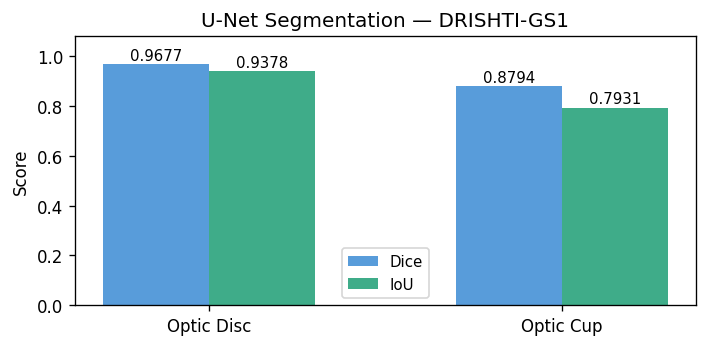

In [9]:
seg_df = pd.read_csv(RESULTS_DIR / 'segmentation_metrics.csv')
print('U-Net Segmentation (DRISHTI-GS1, n=50 training images)')
display(seg_df.round(4).set_index('target'))

fig, ax = plt.subplots(figsize=(6, 3))
x, w = np.arange(2), 0.3
for i, (col, colour, label) in enumerate([
    ('dice','#3B8BD4','Dice'), ('iou','#1D9E75','IoU')
]):
    bars = ax.bar(x + (i-0.5)*w, seg_df[col], w, label=label, color=colour, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(seg_df['target'])
ax.set_ylim([0,1.08]); ax.set_ylabel('Score')
ax.set_title('U-Net Segmentation — DRISHTI-GS1')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'segmentation_summary.png', bbox_inches='tight')
plt.show()

## 9.8 Final ROC figure — all models (300 DPI)

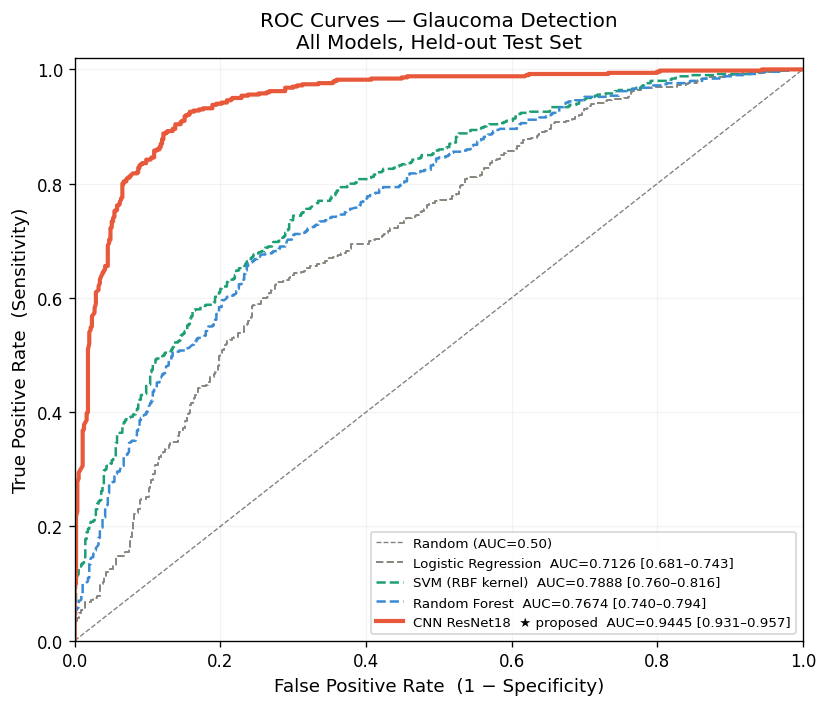

Saved at 300 DPI — paper ready


In [10]:
roc_data   = joblib.load(RESULTS_DIR / 'classical_ml_roc_data.pkl')
style_map  = {
    'LogisticRegression': ('#888780','--',1.2,'Logistic Regression'),
    'SVM_RBF':            ('#1D9E75','--',1.5,'SVM (RBF kernel)'),
    'RandomForest':       ('#3B8BD4','--',1.5,'Random Forest'),
    'CNN (ResNet18)':     ('#E8593C','-', 2.5,'CNN ResNet18  ★ proposed'),
}

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot([0,1],[0,1],'k--',lw=0.8,label='Random (AUC=0.50)',alpha=0.5)

entries = list(roc_data.items()) + [
    ('CNN (ResNet18)', {'fpr': cnn_results['fpr'], 'tpr': cnn_results['tpr'],
                        'auc': cnn_results['auc']})
]
for name, data in entries:
    colour, ls, lw, label = style_map.get(name, ('#999','--',1,name))
    ci  = ci_results.get(name,{}).get('auc',{})
    ci_str = f" [{ci.get('lower',0):.3f}–{ci.get('upper',0):.3f}]" if ci else ''
    ax.plot(data['fpr'], data['tpr'], color=colour, ls=ls, lw=lw,
            label=f"{label}  AUC={data['auc']:.4f}{ci_str}")

ax.set_xlabel('False Positive Rate  (1 − Specificity)', fontsize=11)
ax.set_ylabel('True Positive Rate  (Sensitivity)', fontsize=11)
ax.set_title('ROC Curves — Glaucoma Detection\nAll Models, Held-out Test Set', fontsize=12)
ax.legend(fontsize=8, loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
ax.grid(True, alpha=0.15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'final_roc_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved at 300 DPI — paper ready')

## 9.9 Error analysis — False Negative breakdown

In [11]:
fn_df = cnn_test_df[(cnn_test_df['label']==1) & (cnn_test_df['y_pred']==0)]
tp_df = cnn_test_df[(cnn_test_df['label']==1) & (cnn_test_df['y_pred']==1)]

print(f'False Negatives (missed glaucoma) : {len(fn_df)}')
print(f'True  Positives (caught glaucoma) : {len(tp_df)}')
print(f'Miss rate                         : {len(fn_df)/(len(fn_df)+len(tp_df)):.2%}')
print(f'\nFN by dataset:')
print(fn_df['dataset'].value_counts().to_string())
print(f'\nFN confidence scores (y_prob):')
print(fn_df['y_prob'].describe().round(3).to_string())

False Negatives (missed glaucoma) : 34
True  Positives (caught glaucoma) : 466
Miss rate                         : 6.80%

FN by dataset:
dataset
AIROGS    24
RIMONE     6
ACRIMA     4

FN confidence scores (y_prob):
count    34.000
mean      0.223
std       0.153
min       0.016
25%       0.098
50%       0.182
75%       0.363
max       0.481


## 9.10 Complete output summary

In [ ]:
print('═'*62)
print('  FINAL RESULTS SUMMARY')
print('═'*62)
print(f'Datasets  : ACRIMA + RIM-ONE DL + EyePACS-AIROGS')
print(f'Test set  : {len(y_test)} samples (classical) / {len(y_true_cnn)} (CNN)')

print('\n── Classification Results ─────────────────────────────────')
for name, ci in ci_results.items():
    a, s, sp = ci['auc'], ci['sensitivity'], ci['specificity']
    tag = '  ← PROPOSED' if 'CNN' in name else ''
    print(f'  {name:<22}  AUC {a["mean"]:.4f} [{a["lower"]:.4f}–{a["upper"]:.4f}]'
        f'  Sen {s["mean"]:.4f}  Spe {sp["mean"]:.4f}{tag}')

print('\n── Segmentation Results (DRISHTI-GS1) ─────────────────────')
for _, row in seg_df.iterrows():
    print(f'  {row["target"]:<15}  Dice {row["dice"]:.4f}   IoU {row["iou"]:.4f}')

print('\n── Saved Outputs ──────────────────────────────────────────')
all_files = sorted(list(RESULTS_DIR.glob('*.csv')) + list(RESULTS_DIR.glob('*.pkl')))
for f in all_files:
    print(f'  results/{f.name}')
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(f'  figures/{f.name}')
print('═'*62)

══════════════════════════════════════════════════════════════
  FINAL RESULTS SUMMARY
══════════════════════════════════════════════════════════════
Datasets  : ACRIMA + RIM-ONE DL + EyePACS-AIROGS
Test set  : 1050 samples (classical) / 1050 (CNN)

── Classification Results ─────────────────────────────────
  LogisticRegression      AUC 0.7126 [0.6808–0.7434]  Sen 0.6700  Spe 0.6491
  SVM_RBF                 AUC 0.7888 [0.7597–0.8155]  Sen 0.7660  Spe 0.6673
  RandomForest            AUC 0.7674 [0.7399–0.7940]  Sen 0.7140  Spe 0.6891
  CNN (ResNet18)          AUC 0.9445 [0.9305–0.9574]  Sen 0.9320  Spe 0.8164  ← PROPOSED

── Segmentation Results (DRISHTI-GS1) ─────────────────────
  Optic Disc       Dice 0.9677   IoU 0.9378
  Optic Cup        Dice 0.8794   IoU 0.7931

── Saved Outputs ──────────────────────────────────────────
  results/all_models_comparison.csv
  results/classical_ml_pub_table.csv
  results/classical_ml_results.csv
  results/classical_ml_roc_data.pkl
  results/cnn_te

---
## ✅ All phases complete

### Paper-ready outputs

**Tables** — `outputs/results/`
- `final_results_table.csv` — main results with 95% CI
- `cross_dataset_cnn.csv` — generalisation table
- `segmentation_metrics.csv` — U-Net Dice/IoU
- `classical_ml_pub_table.csv` — classical ML detail
- `gradcam_focus_scores.csv` — explainability stats

**Figures** — `outputs/figures/` (all 300 DPI)
- `final_roc_curves.png` — main comparison figure
- `gradcam_publication_figure.png` — explainability
- `unet_segmentation_results.png` — segmentation
- `cross_dataset_performance.png` — generalisation
- `cnn_training_curves.png` — training dynamics
- `cdr_proxy_vs_unet.png` — CDR improvement story

**Models** — `outputs/models/`
- `glaucoma_resnet18_best.pth`
- `disc_unet_best.pth` + `cup_unet_best.pth`
- `LogisticRegression_best.pkl` + `SVM_RBF_best.pkl` + `RandomForest_best.pkl`
